# 2. EDA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
plt.rcParams["figure.dpi"] = 140
plt.rcParams["font.size"] = 10
sns.set_style("whitegrid")

palette = {
    "Africa": "#D55E00",
    "Asia": "#0072B2",
    "Australia": "#E69F00",
    "Europe": "#009E73",
    "North America": "#CC79A7",
    "South America": "#56B4E9"
}

In [3]:
df = pd.read_csv("data/processed/weather/master_long.csv", parse_dates=["date"])
annual_city = pd.read_csv("data/processed/weather/annual_city.csv")
global_annual = pd.read_csv("data/processed/weather/global_annual.csv")

print("Daily data shape :", df.shape)
print("Annual city data shape :", annual_city.shape)
print("Global annual data shape :", global_annual.shape)

Daily data shape : (54795, 22)
Annual city data shape : (150, 14)
Global annual data shape : (10, 7)


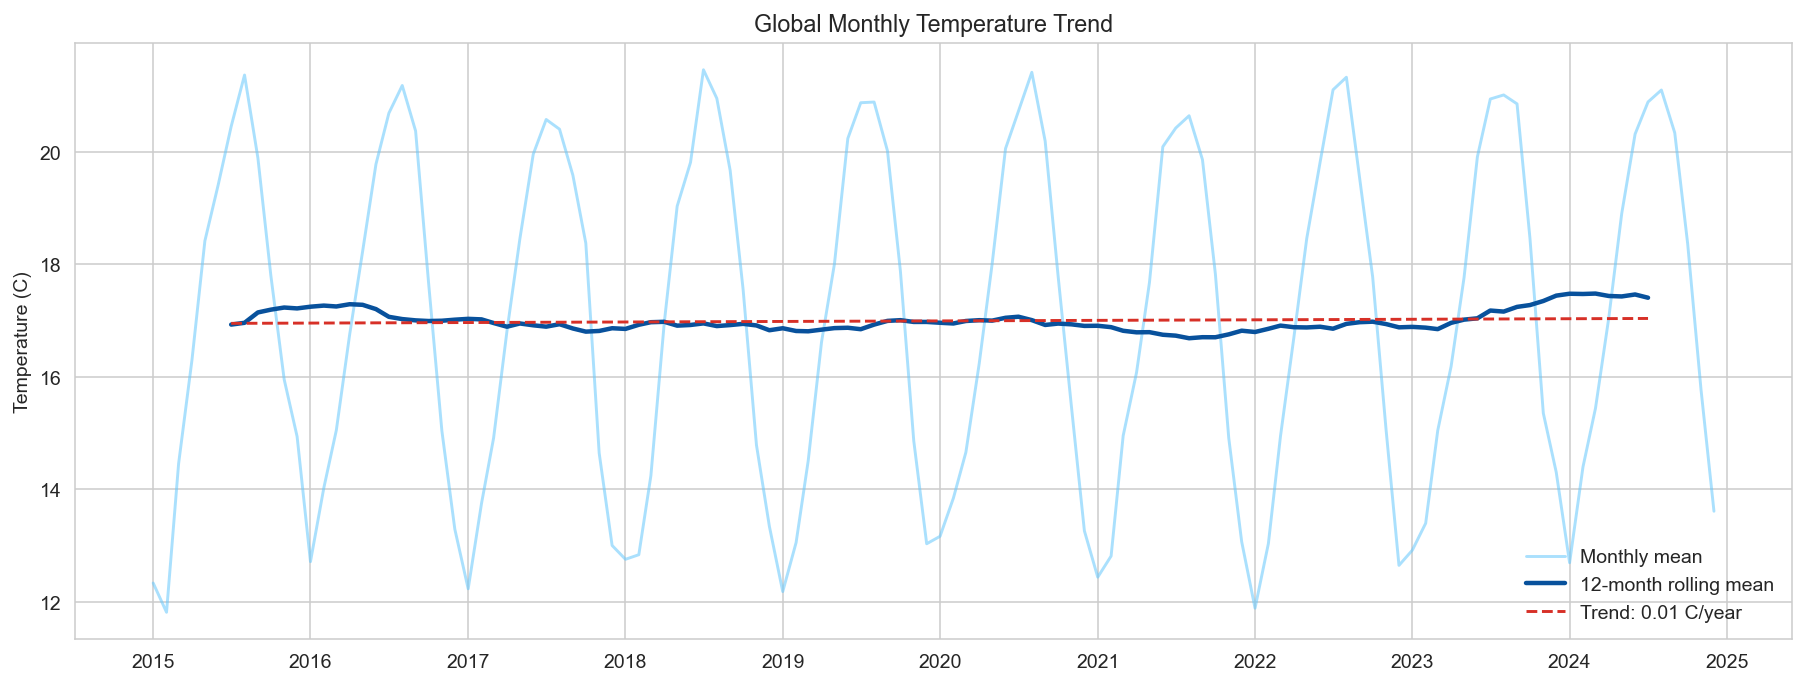

In [28]:
monthly_global = df.groupby(df["date"].dt.to_period("M"))["temp_mean"].mean().reset_index()
monthly_global["date"] = monthly_global["date"].dt.to_timestamp()
monthly_global["rolling_12m"] = monthly_global["temp_mean"].rolling(12, center=True).mean()

x = np.arange(len(monthly_global))
valid = monthly_global["rolling_12m"].notnull()
slope, intercept = np.polyfit(x[valid], monthly_global.loc[valid, "rolling_12m"], 1)

plt.figure(figsize=(13, 5))
plt.plot(monthly_global["date"], monthly_global["temp_mean"], color="#65c7fc", alpha=0.55, label="Monthly mean")
plt.plot(monthly_global["date"], monthly_global["rolling_12m"], color="#08519c", linewidth=2.3, label="12-month rolling mean")
plt.plot(monthly_global["date"][valid], slope * x[valid] + intercept, color="#d73027", linestyle="--",
         label=f"Trend: {slope * 12:.2f} C/year")
plt.title("Global Monthly Temperature Trend")
plt.ylabel("Temperature (C)")
plt.xlabel("")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

### Insights
1. The 12-month rolling average smooths short-term seasonal variation and makes the long-term pattern easier to observe.
2. The fitted trend line shows a positive trend of about 0.01 C per year based on the collected city sample.
3. Monthly temperatures fluctuate strongly due to seasonality, so rolling averages are more useful than raw monthly values for trend interpretation.


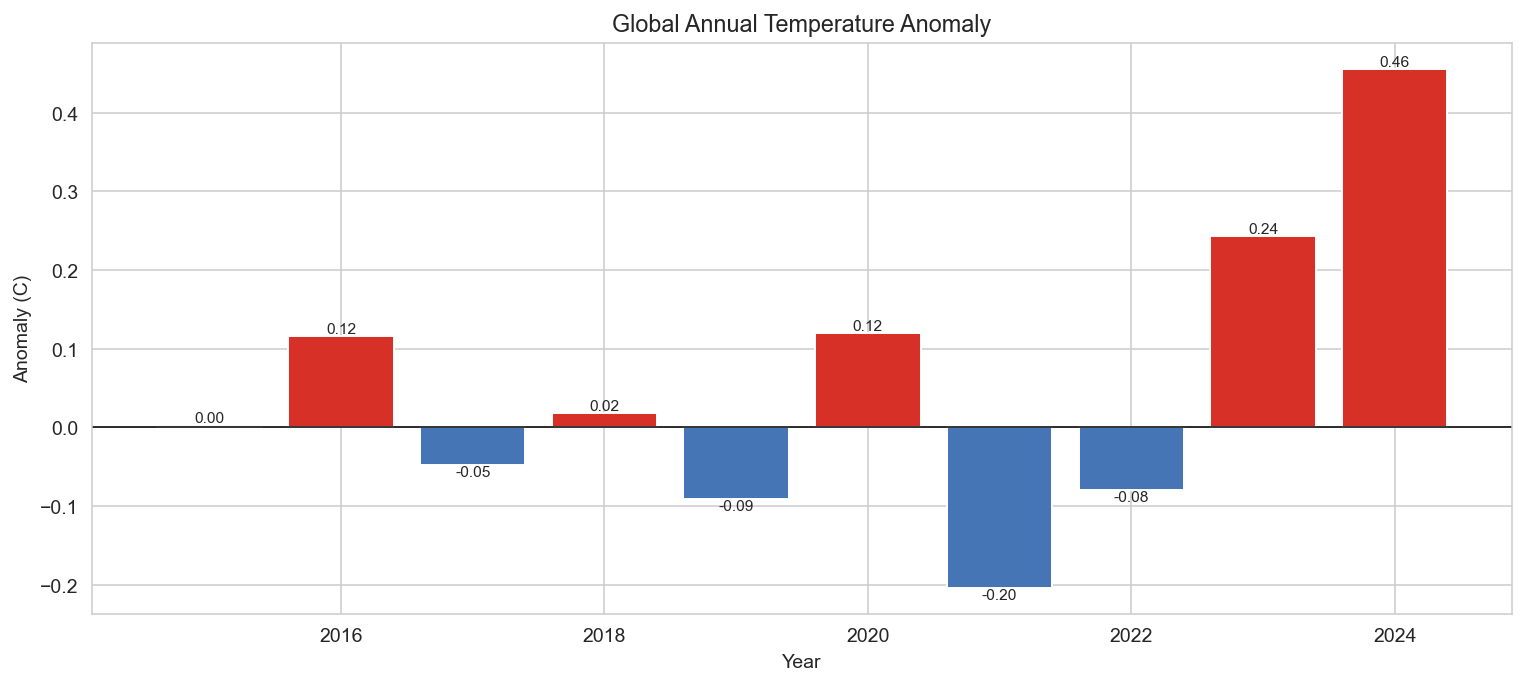

In [10]:
colors = np.where(global_annual["global_anomaly_mean"] >= 0, "#d73027", "#4575b4")

plt.figure(figsize=(11, 5))
bars = plt.bar(global_annual["year"], global_annual["global_anomaly_mean"], color=colors)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Global Annual Temperature Anomaly")
plt.ylabel("Anomaly (C)")
plt.xlabel("Year")

for bar, value in zip(bars, global_annual["global_anomaly_mean"]):
    plt.text(bar.get_x() + bar.get_width()/2, value, f"{value:.2f}",
             ha="center", va="bottom" if value >= 0 else "top", fontsize=8)

plt.tight_layout()
plt.show()


### Insights
1. The annual anomaly increased from about 0.00 C in 2015 to about 0.46 C in 2024.
2. Later years show more positive anomaly values, which suggests warming relative to the baseline period(2015-19) used in this project.
3. Since anomalies are calculated relative to city-specific baseline temperatures, they are more reliable.
4. Year 2021-22 having negative anomaly may be due to Covid time that industry work have declined their rate which decreased pollution and greenhouse gas emmision. That is why pollution is positively correlated with global temperature.  


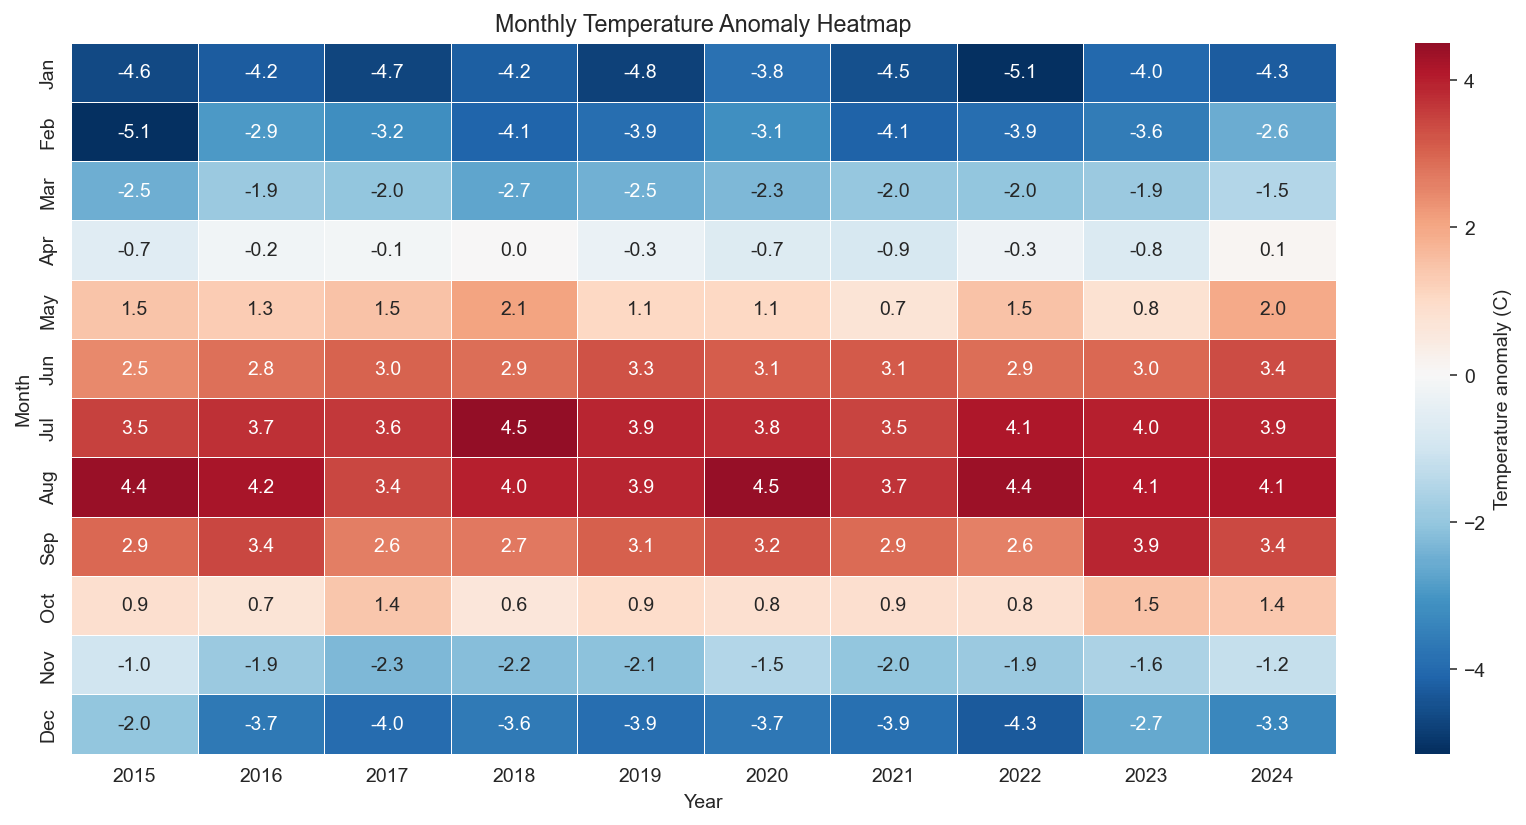

In [13]:
monthly_anomaly = df.groupby(["year", "month"])["temp_anomaly"].mean().reset_index()
heatmap_data = monthly_anomaly.pivot(index="month", columns="year", values="temp_anomaly")
heatmap_data.index = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                      "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".1f",
    linewidths=0.4,
    cbar_kws={"label": "Temperature anomaly (C)"}
)
plt.title("Monthly Temperature Anomaly Heatmap")
plt.xlabel("Year")
plt.ylabel("Month")
plt.tight_layout()
plt.show()


### Insights
1. The heatmap highlights which months and years were warmer or cooler compared with the baseline.
2. Strong positive anomalies are visible in several mid-year months, especially July and August.
3. This chart is useful for detecting seasonal warming patterns, not just yearly averages.


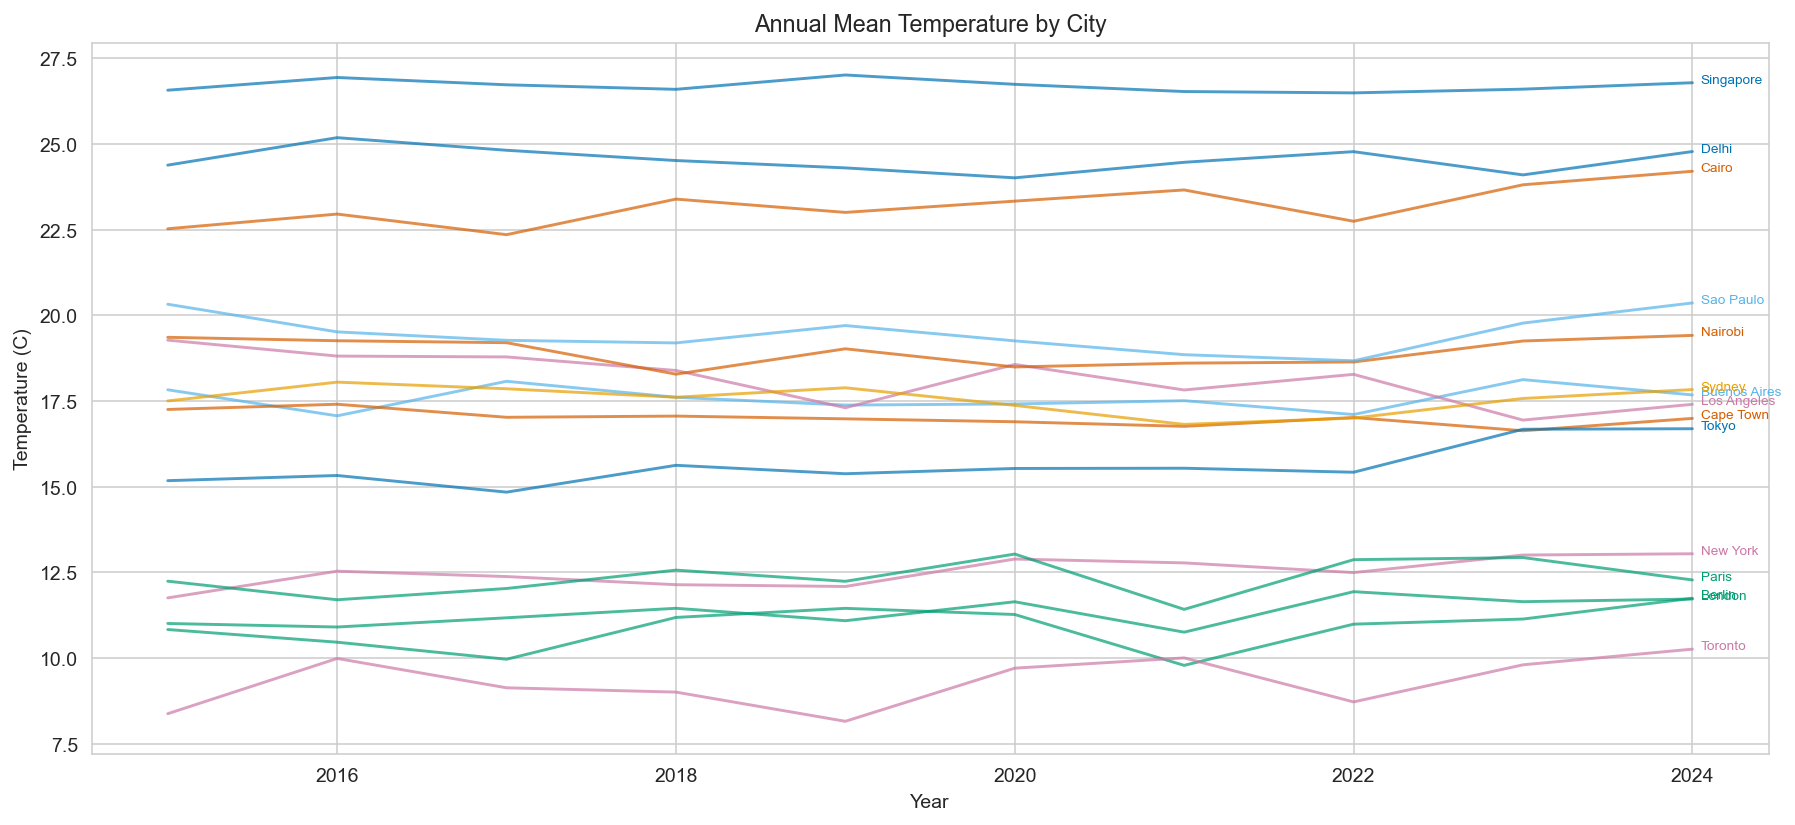

In [14]:
plt.figure(figsize=(13, 6))

for city, city_data in annual_city.groupby("city"):
    city_data = city_data.sort_values("year")
    continent = city_data["continent"].iloc[0]
    plt.plot(
        city_data["year"],
        city_data["temp_annual_mean"],
        color=palette.get(continent, "gray"),
        alpha=0.7,
        linewidth=1.5
    )
    plt.text(
        city_data["year"].iloc[-1] + 0.05,
        city_data["temp_annual_mean"].iloc[-1],
        city,
        fontsize=7,
        color=palette.get(continent, "gray")
    )

plt.title("Annual Mean Temperature by City")
plt.ylabel("Temperature (C)")
plt.xlabel("Year")
plt.tight_layout()
plt.show()


### Insights
1. Cities show different warming behavior, which indicates that temperature change is not uniform across locations.
2. Tokyo, Cairo, New York, and Toronto show some of the strongest positive annual temperature slopes in this dataset.
3. Some cities show weaker or negative slopes, which may be due to local climate variability, coastal effects, or the limited 10-year period.

C:\Users\SUJAL\AppData\Local\Temp\ipykernel_1044\315658717.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


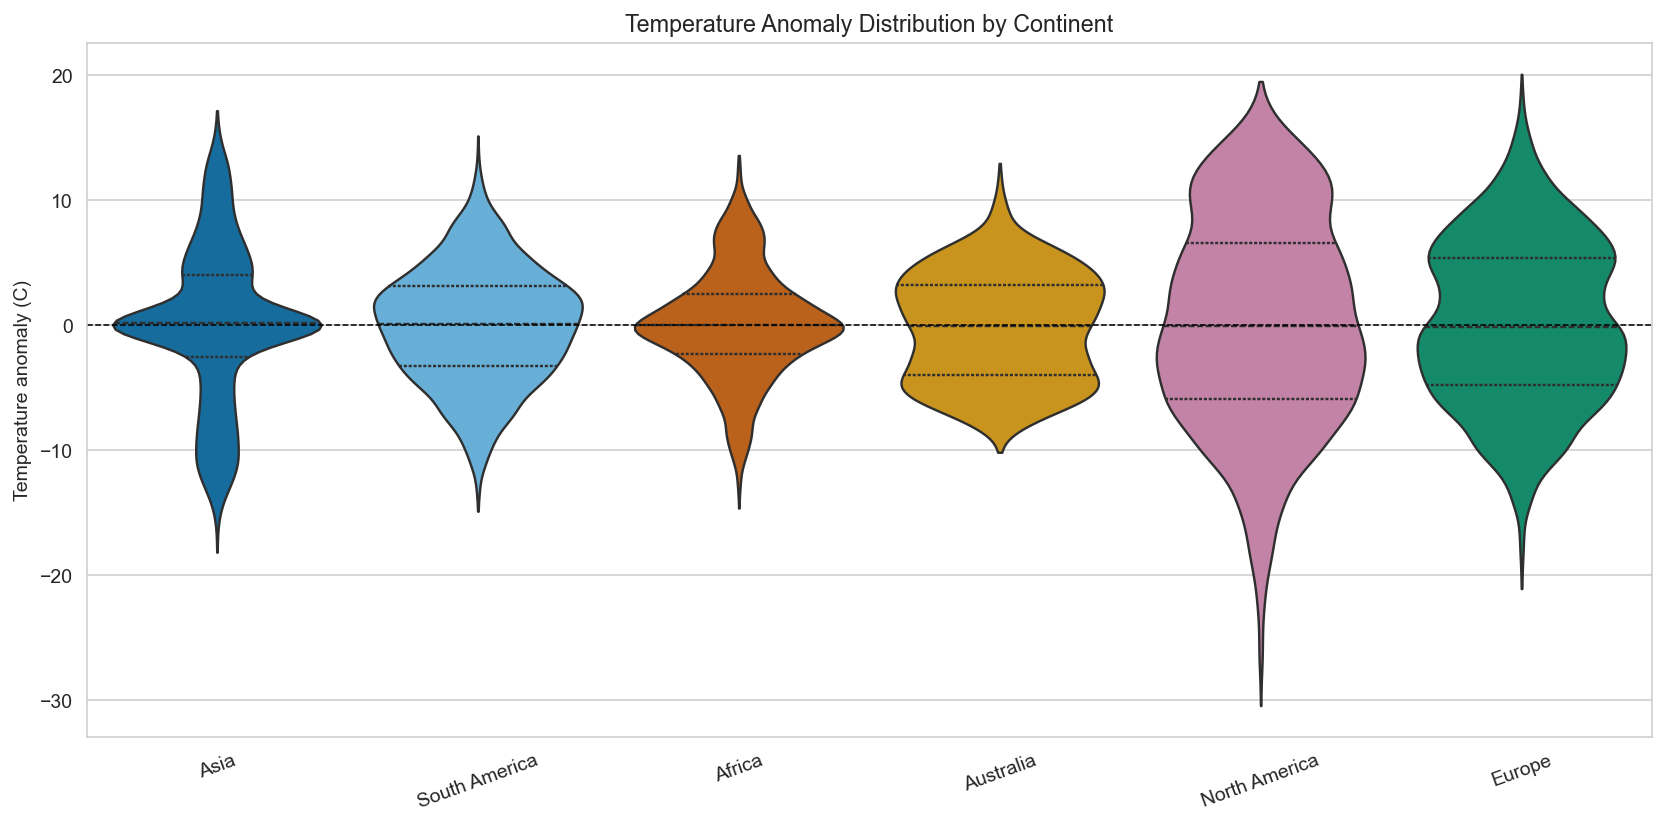

In [16]:
plt.figure(figsize=(12, 6))
continent_order = df.groupby("continent")["temp_anomaly"].median().sort_values(ascending=False).index

sns.violinplot(
    data=df,
    x="continent",
    y="temp_anomaly",
    order=continent_order,
    palette=palette,
    inner="quartile",
    cut=0
)

plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.title("Temperature Anomaly Distribution by Continent")
plt.ylabel("Temperature anomaly (C)")
plt.xlabel("")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


### Insights
1. The violin plot shows both the spread and density of temperature anomalies across continents.
2. Europe and North America have higher average anomalies in this dataset compared with Australia and South America.
3. Wider distributions suggest stronger day-to-day or seasonal variability in anomaly values.
4. Asia and Africa have more density towards center which means average anomaly across the continent is almost 0. Means in other words they are stable since last decade.

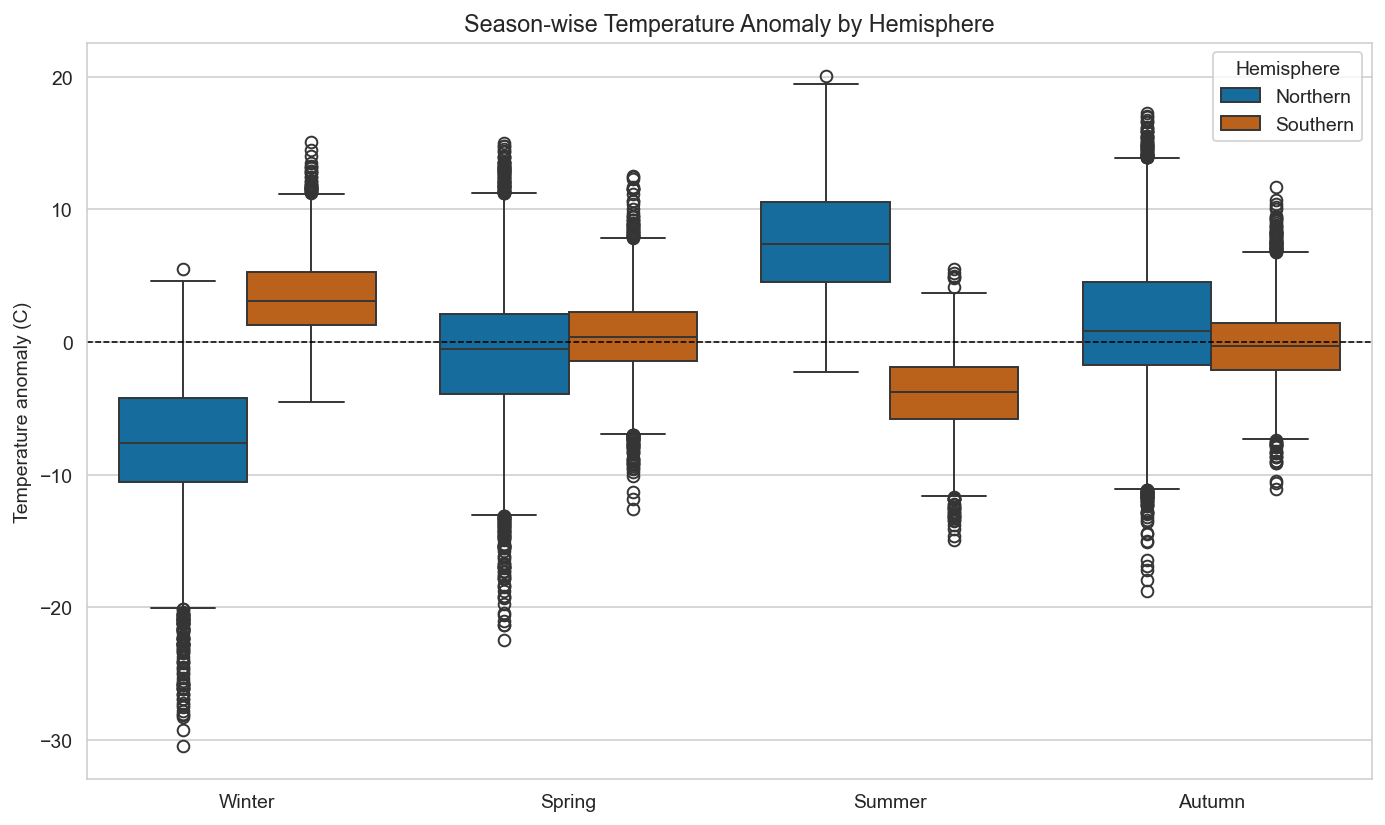

In [18]:
plt.figure(figsize=(10, 6))
season_order = ["Winter", "Spring", "Summer", "Autumn"]

sns.boxplot(
    data=df,
    x="season",
    y="temp_anomaly",
    order=season_order,
    hue="hemisphere",
    palette=["#0072B2", "#D55E00"]
)

plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.title("Season-wise Temperature Anomaly by Hemisphere")
plt.ylabel("Temperature anomaly (C)")
plt.xlabel("")
plt.legend(title="Hemisphere")
plt.tight_layout()
plt.show()


### Insights
1. Seasonal anomaly patterns differ clearly between the Northern and Southern Hemispheres.
2. Northern Hemisphere summer months show high positive anomalies, while winter months show lower values.
3. The opposite seasonal behavior in the Southern Hemisphere confirms that hemisphere should be considered during seasonal analysis. This is due to the fact that southern hemisphere has summers in November to January and I have extracted season column based on northern hemisphere.


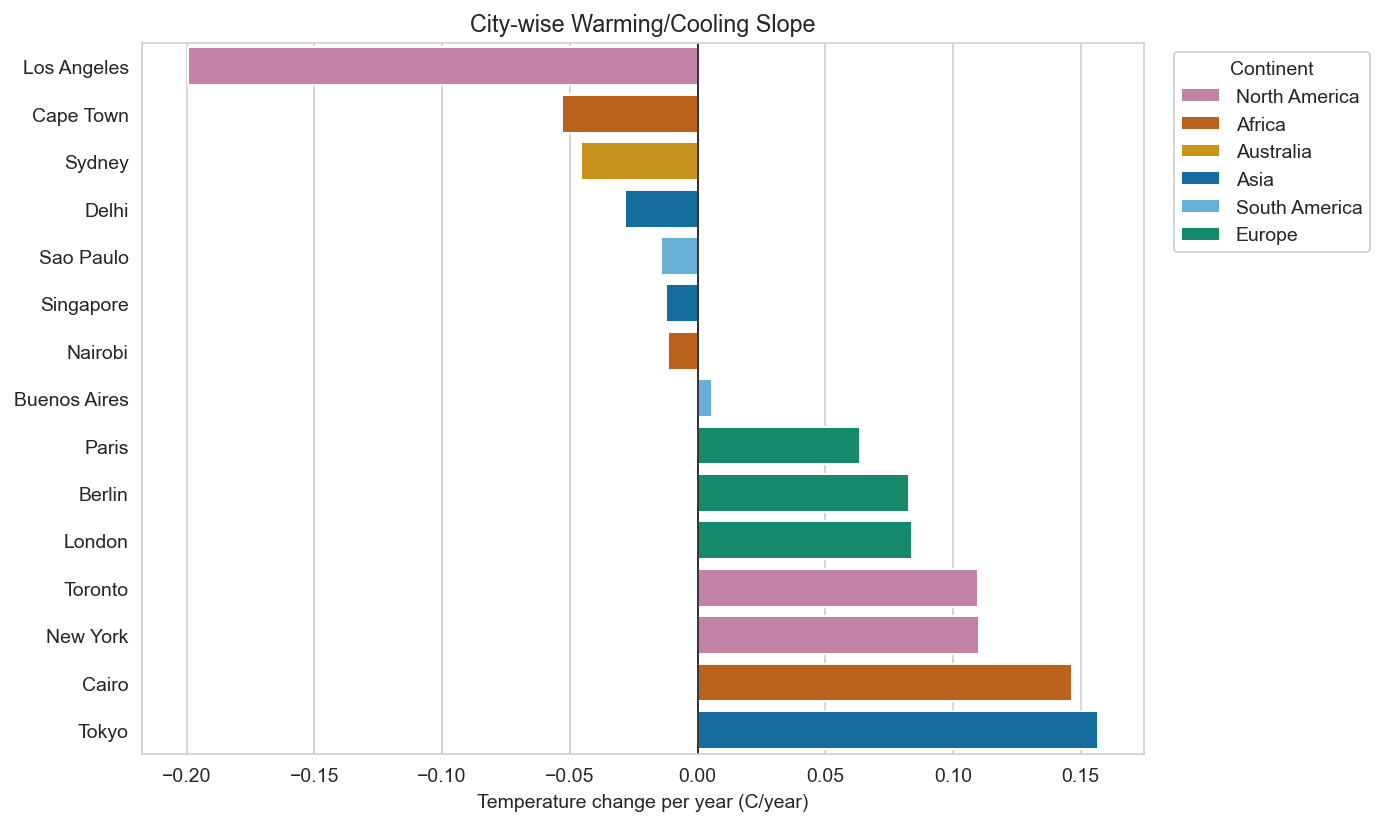

In [20]:
slopes = []

for city, city_data in annual_city.groupby("city"):
    city_data = city_data.sort_values("year")
    slope, intercept = np.polyfit(city_data["year"], city_data["temp_annual_mean"], 1)
    slopes.append({
        "city": city,
        "continent": city_data["continent"].iloc[0],
        "slope_per_year": slope
    })

slope_df = pd.DataFrame(slopes).sort_values("slope_per_year", ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=slope_df,
    x="slope_per_year",
    y="city",
    hue="continent",
    dodge=False,
    palette=palette
)

plt.axvline(0, color="black", linewidth=0.8)
plt.title("City-wise Warming/Cooling Slope")
plt.xlabel("Temperature change per year (C/year)")
plt.ylabel("")
plt.legend(title="Continent", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Insights
1. The slope chart ranks cities by their annual temperature change, making local warming patterns easier to compare.
2. Tokyo and Cairo show the strongest positive slopes among the selected cities.
3. Negative slopes in some cities should not be interpreted as global cooling, because local variation and short study duration can affect city-level trends. Main example of this can be seen in Delhi, may be the max temperature of Delhi is increasing year by year but Delhi have severe winters making its yearly mean stable.


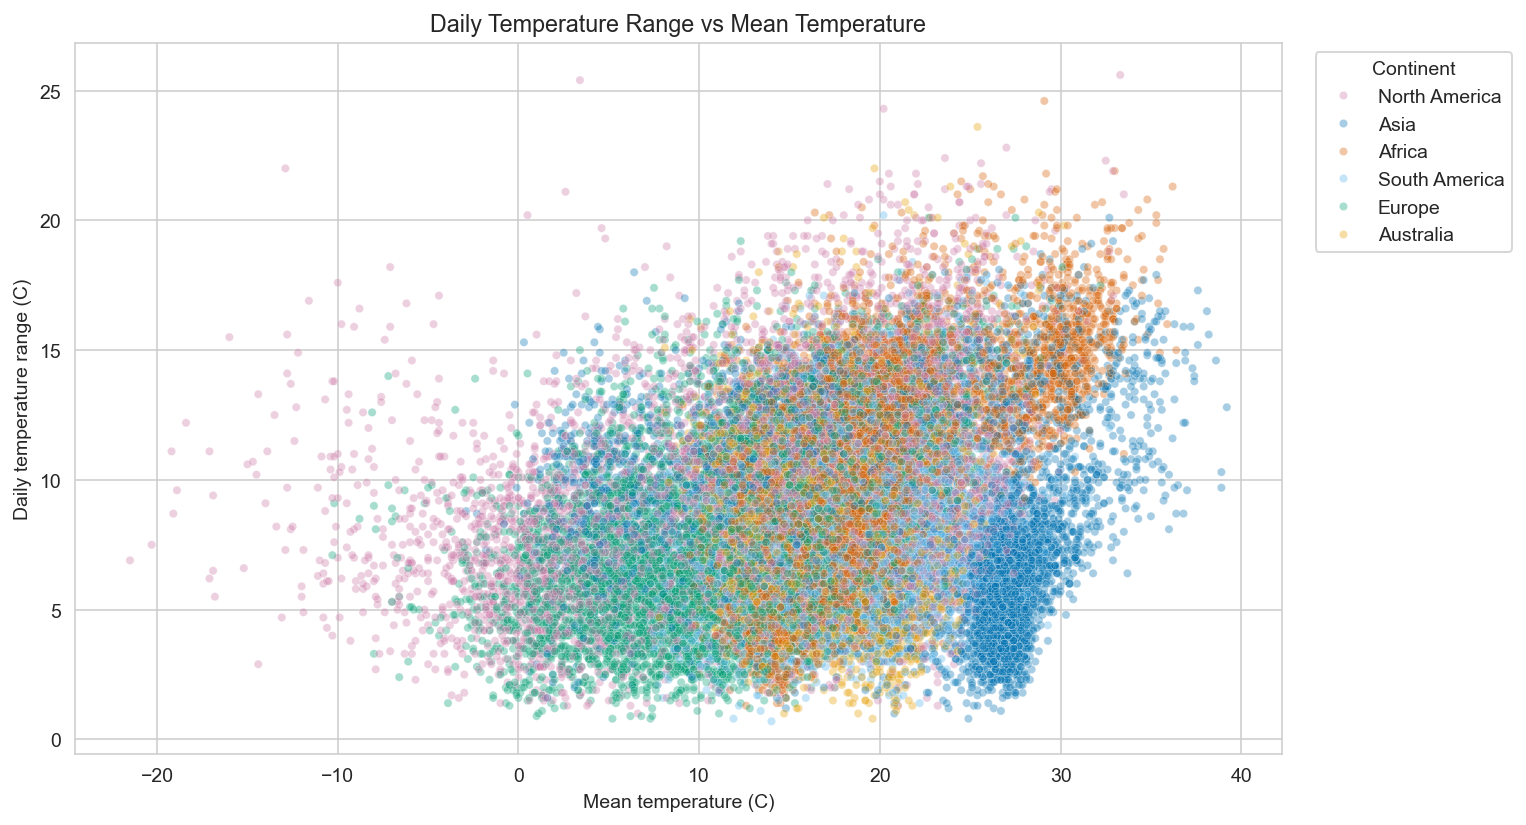

In [22]:
sample_df = df.sample(min(30000, len(df)), random_state=42)

plt.figure(figsize=(11, 6))
sns.scatterplot(
    data=sample_df,
    x="temp_mean",
    y="temp_range_day_wise",
    hue="continent",
    palette=palette,
    alpha=0.35,
    s=18
)

plt.title("Daily Temperature Range vs Mean Temperature")
plt.xlabel("Mean temperature (C)")
plt.ylabel("Daily temperature range (C)")
plt.legend(title="Continent", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Insights
1. The scatter plot shows how daily temperature range changes with average temperature.
2. Cities and continents form different clusters, suggesting that geography influences both average temperature and daily variation.
3. Temperature range is only weakly correlated with mean temperature, so it provides additional information beyond average temperature alone.
4. From this we can see that Asia has the highest mean temperature whereas North America has lowest mean temperature.

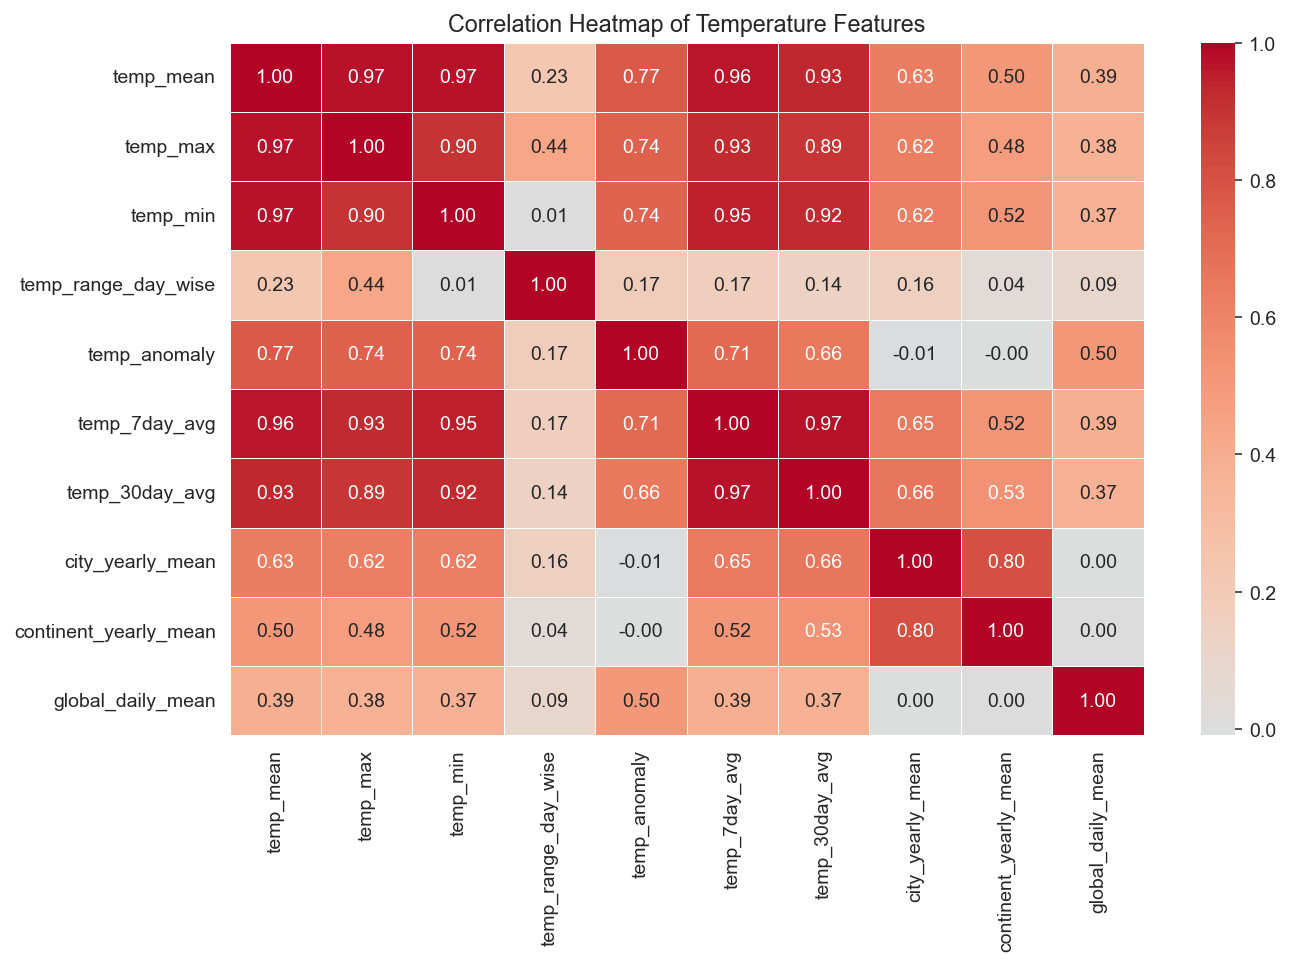

In [24]:
corr_cols = [
    "temp_mean",
    "temp_max",
    "temp_min",
    "temp_range_day_wise",
    "temp_anomaly",
    "temp_7day_avg",
    "temp_30day_avg",
    "city_yearly_mean",
    "continent_yearly_mean",
    "global_daily_mean"
]

corr_data = df[corr_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_data, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.4)
plt.title("Correlation Heatmap of Temperature Features")
plt.tight_layout()
plt.show()


### Insights
1. Mean, maximum, and minimum temperatures are strongly correlated, which is expected because they measure related daily temperature behavior.
2. Rolling averages are highly correlated with mean temperature because they are smoothed versions of the same signal.
3. Temperature range has a much weaker relationship with mean temperature, so it can be useful as a separate feature.


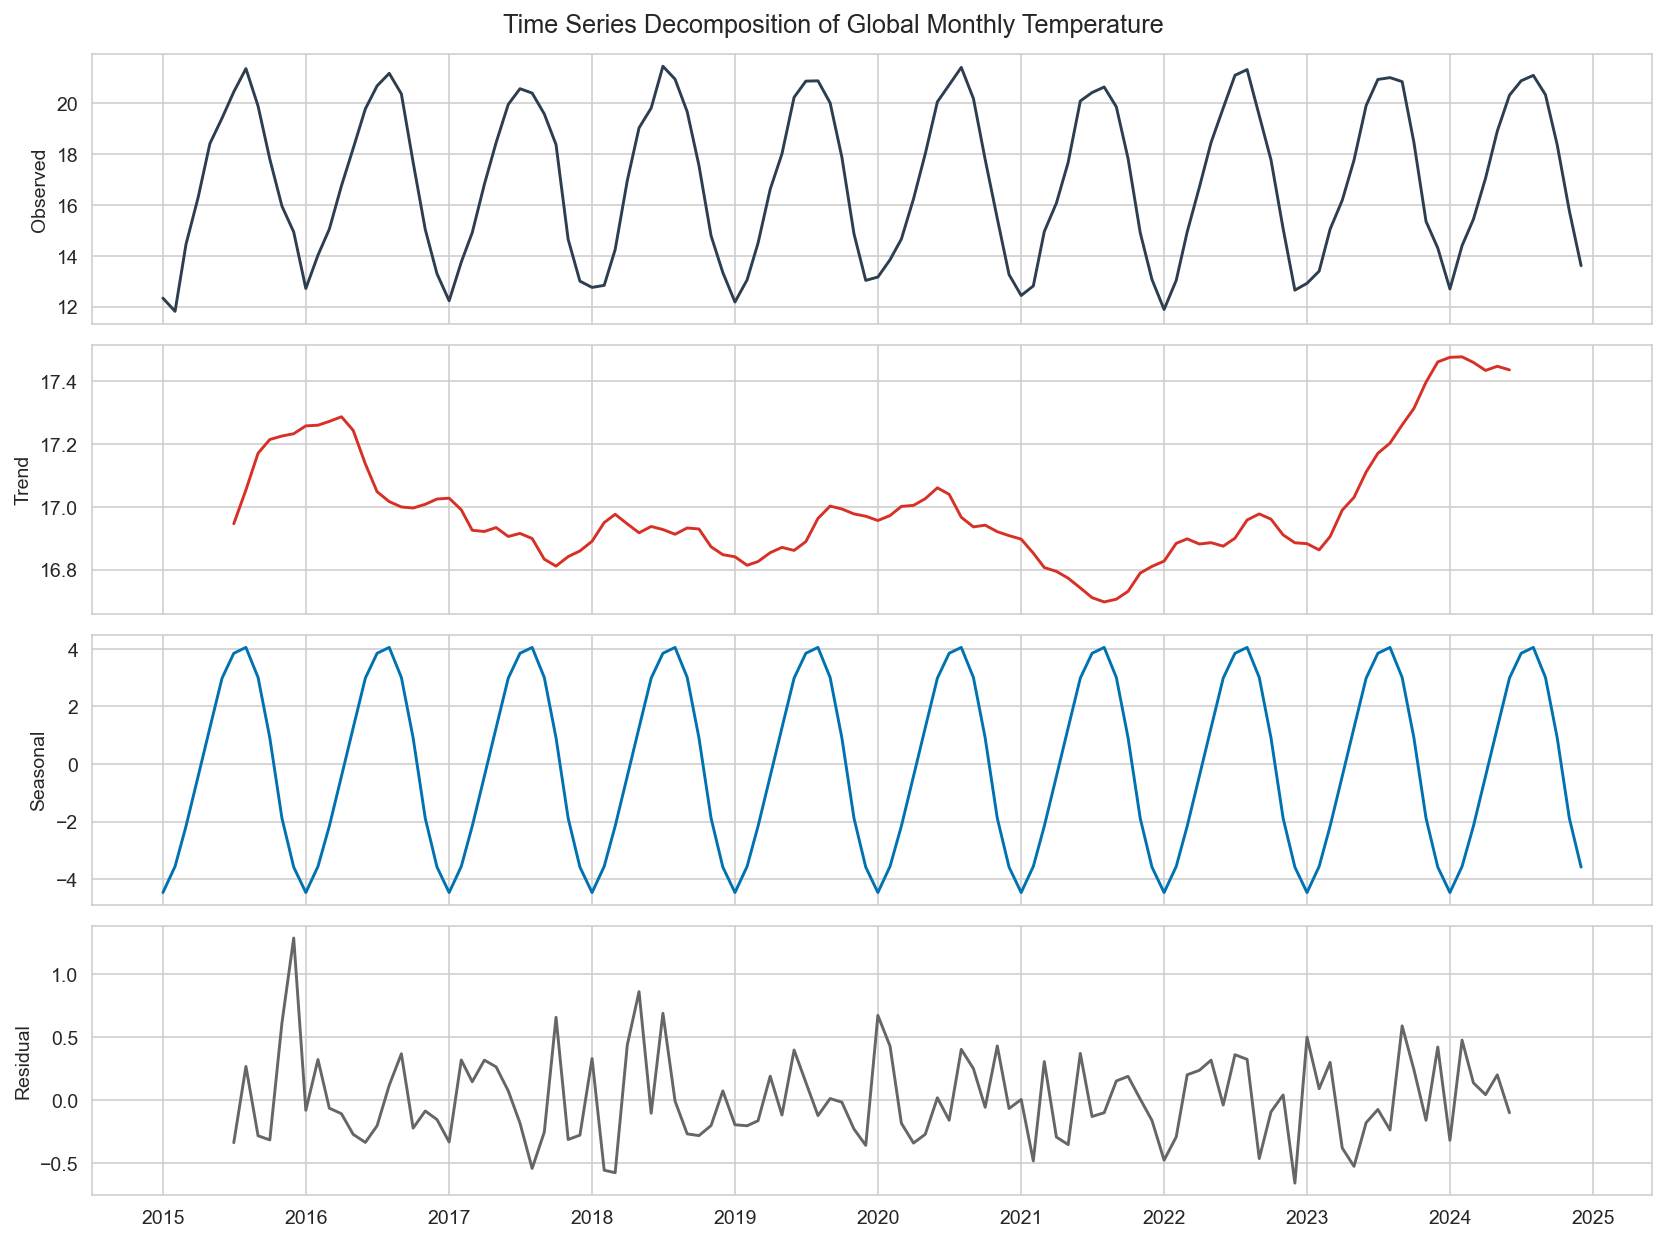

In [25]:
monthly_series = df.groupby(df["date"].dt.to_period("M"))["temp_mean"].mean()
monthly_series.index = monthly_series.index.to_timestamp()
monthly_series = monthly_series.resample("MS").mean().interpolate()

decomp = seasonal_decompose(monthly_series, model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)

axes[0].plot(decomp.observed, color="#2c3e50")
axes[0].set_ylabel("Observed")

axes[1].plot(decomp.trend, color="#d73027")
axes[1].set_ylabel("Trend")

axes[2].plot(decomp.seasonal, color="#0072B2")
axes[2].set_ylabel("Seasonal")

axes[3].plot(decomp.resid, color="#666666")
axes[3].set_ylabel("Residual")

fig.suptitle("Time Series Decomposition of Global Monthly Temperature", fontsize=13)
plt.tight_layout()
plt.show()


### Insights
1. The decomposition separates the global monthly temperature series into trend, seasonality, and residual variation.
2. The seasonal component confirms that temperature follows a strong yearly cycle.
3. The trend component is the most useful part for studying long-term warming behavior which is increasing in recent years.

In [26]:
import plotly.express as px

risk_data = []

for city, city_data in annual_city.groupby("city"):
    city_data = city_data.sort_values("year")
    
    slope, intercept = np.polyfit(
        city_data["year"],
        city_data["temp_annual_mean"],
        1
    )
    
    risk_data.append({
        "city": city,
        "country": city_data["country"].iloc[0],
        "continent": city_data["continent"].iloc[0],
        "latitude": city_data["latitude"].iloc[0],
        "longitude": city_data["longitude"].iloc[0],
        "slope_per_year": slope,
        "slope_per_decade": slope * 10,
        "risk_level": "High Risk" if slope > 0 else "Low Risk"
    })

risk_map_df = pd.DataFrame(risk_data)

risk_map_df


,city,country,continent,latitude,longitude,slope_per_year,slope_per_decade,risk_level
0,Berlin,Germany,Europe,52.5200,13.4050,0.082948,0.829483,High Risk
1,Buenos Aires,Argentina,South America,-34.6037,-58.3816,0.005673,0.056730,High Risk
2,Cairo,Egypt,Africa,30.0444,31.2357,0.146418,1.464180,High Risk
3,Cape Town,South Africa,Africa,-33.9249,18.4241,-0.053200,-0.532004,Low Risk
4,Delhi,India,Asia,28.6139,77.2090,-0.028343,-0.283427,Low Risk
5,London,United Kingdom,Europe,51.5072,-0.1276,0.084015,0.840149,High Risk
6,Los Angeles,USA,North America,34.0522,-118.2437,-0.199472,-1.994724,Low Risk
7,Nairobi,Kenya,Africa,-1.2921,36.8219,-0.011657,-0.116566,Low Risk
8,New York,USA,North America,40.7128,-74.0060,0.110092,1.100916,High Risk
9,Paris,France,Europe,48.8566,2.3522,0.063651,0.636506,High Risk


In [27]:
fig = px.scatter_geo(
    risk_map_df,
    lat="latitude",
    lon="longitude",
    hover_name="city",
    hover_data={
        "country": True,
        "continent": True,
        "slope_per_year": ":.4f",
        "slope_per_decade": ":.3f",
        "latitude": False,
        "longitude": False
    },
    color="risk_level",
    color_discrete_map={
        "High Risk": "red",
        "Low Risk": "blue"
    },
    size=abs(risk_map_df["slope_per_decade"]) + 0.05,
    projection="natural earth",
    title="Global Warming Risk Map Based on City Temperature Trends"
)

fig.update_geos(
    showland=True,
    landcolor="rgb(235, 235, 235)",
    showocean=True,
    oceancolor="rgb(220, 235, 250)",
    showcountries=True,
    countrycolor="white"
)

fig.update_layout(
    height=600,
    legend_title_text="Risk Level",
    margin=dict(l=10, r=10, t=60, b=10)
)

fig.show()


### Insights
1. Europe, Japan and New York region is in very high risk of global warming which is a concerning matter. As these countries are away from equator and cooler, due to global warming temperatures are rising and it increases the global temperature on a huge scale.
2. This doesn't mean places India, temperature is not rising, the point is that global warming has affected cooler regions more by drastically changing their temperatures, temperature near equator also rose but it was already warm so the change is not much.